In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import scipy
    import sklearn
    import statsmodels
except ImportError:
    install('scipy')
    install('scikit-learn')
    install('statsmodels')

print("all packages ready")

# Stochastic Interest Rate Modelling and Prediction

**Model:** Cox-Ingersoll-Ross (CIR)  
**Data:** Historical Bond Yield Time Series (9 maturities)  
**Goal:** Calibrate CIR, reconstruct yield curve from 3M rate only, out-of-sample R² > 0.85

---

## Table of Contents
1. Data Engineering & Preprocessing  
2. CIR Model — Theory & Implementation  
3. Parameter Calibration (MLE / OLS)  
4. Feller Condition Analysis  
5. Yield Curve Reconstruction  
6. Prediction from 3M Rate Only  
7. Evaluation & Backtesting  
8. Advanced Extension  
9. Critical Analysis  
10. Conclusions

In [ ]:
import os

# colab needs to mount drive; local just uses relative path
IS_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # update this to wherever you put the data folder in your drive
    DATA_DIR = '/content/drive/MyDrive/stochastic-ir-modelling/data'
    print("running on colab — drive mounted")
else:
    DATA_DIR = '../data'
    print("running locally")

TRAIN_PATH   = os.path.join(DATA_DIR, 'train_data.csv')
TEST_PATH    = os.path.join(DATA_DIR, 'test_data.csv')
TEST_3M_PATH = os.path.join(DATA_DIR, 'test_data_3M.csv')

print(f"train  : {TRAIN_PATH}")
print(f"test   : {TEST_PATH}")
print(f"test3m : {TEST_3M_PATH}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")


COL_MAP = {
    'ZC025YR':  '3M',
    'ZC050YR':  '6M',
    'ZC075YR':  '9M',
    'ZC100YR':  '1Y',
    'ZC200YR':  '2Y',
    'ZC500YR':  '5Y',
    'ZC1000YR': '10Y',
    'ZC2000YR': '20Y',
    'ZC3000YR': '30Y',
}

MATURITY_YEARS = {
    '3M':  0.25,
    '6M':  0.50,
    '9M':  0.75,
    '1Y':  1.00,
    '2Y':  2.00,
    '5Y':  5.00,
    '10Y': 10.0,
    '20Y': 20.0,
    '30Y': 30.0,
}

train_raw   = pd.read_csv(TRAIN_PATH)
test_raw    = pd.read_csv(TEST_PATH)
test_3m_raw = pd.read_csv(TEST_3M_PATH)

print(f"train raw shape : {train_raw.shape}")
print(f"test  raw shape : {test_raw.shape}")
print(f"test 3M   shape : {test_3m_raw.shape}")

train raw shape : (1976, 10)
test  raw shape : (495, 6)
test 3M   shape : (495, 2)


In [2]:
def clean_yields(df, col_map=COL_MAP):
    """
    takes raw csv df and returns a clean version:
    - strips col name spaces + renames to readable labels
    - parses date column
    - sorts by date (just in case)
    - handles any remaining NaNs via forward fill then back fill
    """
    df = df.copy()

    # strip leading/trailing spaces from col names
    df.columns = df.columns.str.strip()

    # map raw codes → readable names; only rename cols that exist in this df
    rename = {k.strip(): v for k, v in col_map.items() if k.strip() in df.columns}
    df = df.rename(columns=rename)

    # parse date — some rows might have weird formats so errors='coerce' is safe
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # drop rows where date parsing failed
    bad_dates = df['Date'].isna().sum()
    if bad_dates > 0:
        print(f"  dropped {bad_dates} rows with unparseable dates")
    df = df.dropna(subset=['Date'])

    # sort chronologically — critical for time-delta calcs later
    df = df.sort_values('Date').reset_index(drop=True)

    # forward fill then back fill for any NaNs in yield cols
    # ffill first bc yield data is autocorrelated — yesterday is best guess
    yield_cols = [c for c in df.columns if c != 'Date']
    df[yield_cols] = df[yield_cols].ffill().bfill()

    return df


train = clean_yields(train_raw)
test  = clean_yields(test_raw)
test_3m = clean_yields(test_3m_raw)

print("train:", train.shape, "| date range:", train['Date'].min().date(), "→", train['Date'].max().date())
print("test :", test.shape,  "| date range:", test['Date'].min().date(),  "→", test['Date'].max().date())
print("\nTrain columns:", train.columns.tolist())
print("Test  columns:", test.columns.tolist())
print("\nAny NaNs left?")
print("train:", train.isnull().sum().sum(), "| test:", test.isnull().sum().sum())

train: (1976, 10) | date range: 2016-05-19 → 2024-04-26
test : (495, 6) | date range: 2024-04-29 → 2026-04-29

Train columns: ['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test  columns: ['Date', '3M', '6M', '9M', '1Y', '2Y']

Any NaNs left?
train: 0 | test: 0


In [3]:
def detect_and_clip_outliers(df, z_thresh=4.0):
    """
    flags and clips yield values that are statistically extreme
    using z-score per column. z=4 is conservative — only catches
    real data errors, not just high-vol periods
    """
    df = df.copy()
    yield_cols = [c for c in df.columns if c != 'Date']
    
    outlier_report = {}
    for col in yield_cols:
        z = np.abs(stats.zscore(df[col].dropna()))
        n_outliers = (z > z_thresh).sum()
        outlier_report[col] = n_outliers

        # clip to [mean - 4std, mean + 4std]
        mu, sigma = df[col].mean(), df[col].std()
        df[col] = df[col].clip(lower=mu - z_thresh*sigma,
                               upper=mu + z_thresh*sigma)

    print("Outliers detected (z > 4.0) per maturity:")
    for col, count in outlier_report.items():
        flag = " ← clipped" if count > 0 else ""
        print(f"  {col:>4s}: {count}{flag}")
    
    return df


train = detect_and_clip_outliers(train)
test  = detect_and_clip_outliers(test)

print("\nPost-cleaning train stats (yields as decimals):")
print(train.describe().round(6))

Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0
    5Y: 0
   10Y: 0
   20Y: 0
   30Y: 0
Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0

Post-cleaning train stats (yields as decimals):
                             Date           3M           6M           9M  \
count                        1976  1976.000000  1976.000000  1976.000000   
mean   2020-05-05 23:02:25.748987     0.016699     0.017885     0.018529   
min           2016-05-19 00:00:00     0.000486     0.000878     0.001054   
25%           2018-05-10 18:00:00     0.004622     0.005190     0.005449   
50%           2020-05-05 12:00:00     0.011912     0.013815     0.015304   
75%           2022-04-29 18:00:00     0.017112     0.019378     0.021077   
max           2024-04-26 00:00:00     0.051962     0.053195     0.054040   
std                           NaN     0.016642     0.016760     0.016650   

                1Y           2Y           

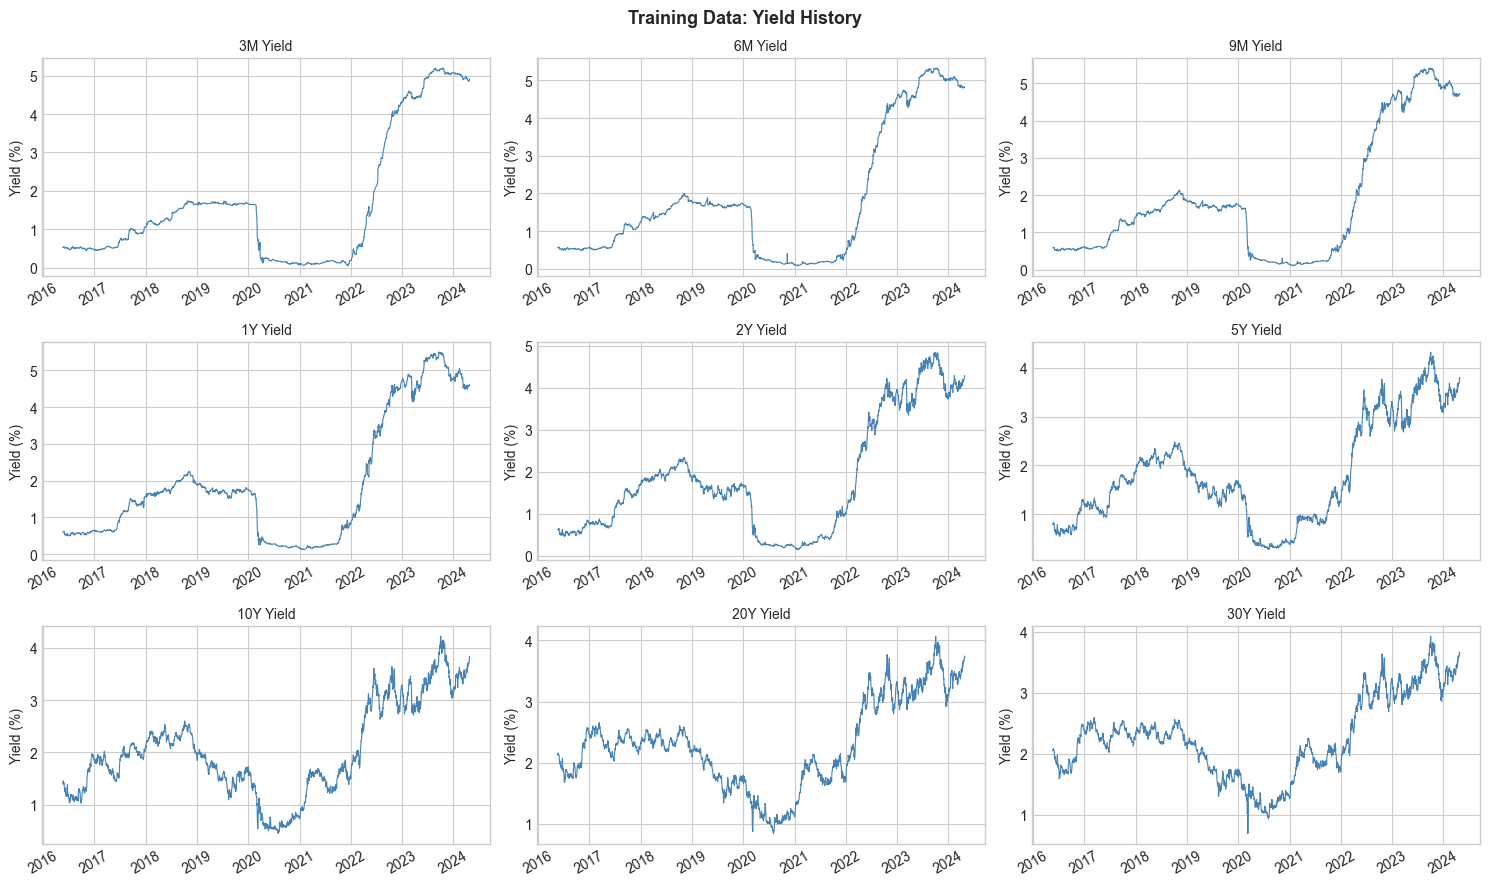

In [4]:
def plot_yield_history(df, title="Training Data: Yield History"):
    """quick look at all maturities over time — useful sanity check"""
    yield_cols = [c for c in df.columns if c != 'Date']
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 9))
    axes = axes.flatten()
    
    for i, col in enumerate(yield_cols):
        axes[i].plot(df['Date'], df[col] * 100, linewidth=0.8, color='steelblue')
        axes[i].set_title(f"{col} Yield", fontsize=10)
        axes[i].set_ylabel("Yield (%)")
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axes[i].tick_params(axis='x', rotation=30)
    
    # hide unused subplots if fewer than 9 cols
    for j in range(len(yield_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_yield_history(train)

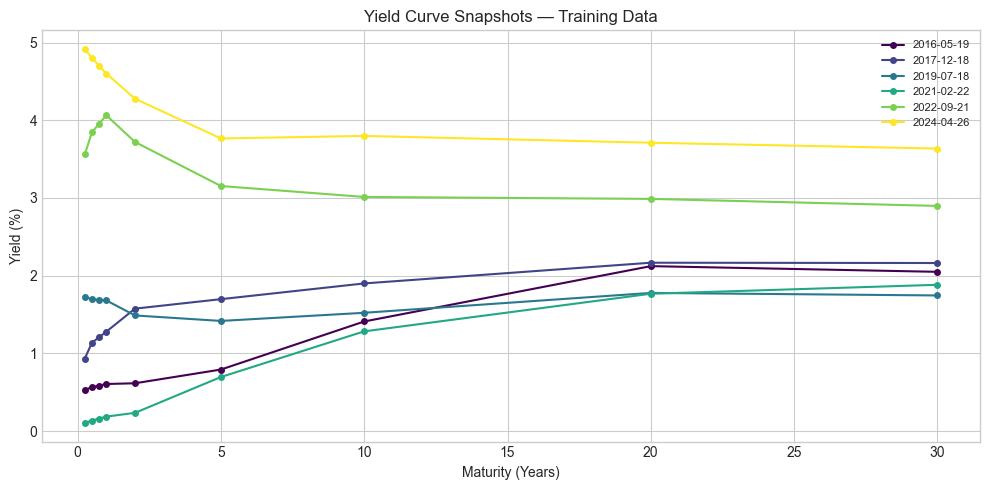

In [5]:
def plot_yield_curve_snapshots(df, n_snapshots=6):
    """
    pick a few evenly spaced dates and plot the yield curve shape
    good way to see if the data looks like a real yield curve
    """
    maturities_in_df = [c for c in df.columns if c != 'Date']
    tenor_years = [MATURITY_YEARS[m] for m in maturities_in_df]
    
    # pick n evenly spaced rows
    idx = np.linspace(0, len(df)-1, n_snapshots, dtype=int)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
    
    for i, row_idx in enumerate(idx):
        row = df.iloc[row_idx]
        yields_pct = [row[m] * 100 for m in maturities_in_df]
        label = str(row['Date'].date())
        ax.plot(tenor_years, yields_pct, marker='o', markersize=4,
                label=label, color=cmap[i], linewidth=1.5)
    
    ax.set_xlabel("Maturity (Years)")
    ax.set_ylabel("Yield (%)")
    ax.set_title("Yield Curve Snapshots — Training Data")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_yield_curve_snapshots(train)
# train only has all 9 maturities — good for this plot

---

## Section 2: The CIR Model — Theory

### Why CIR?

The simplest interest rate model (Vasicek) allows rates to go negative.  
CIR fixes this with a square-root diffusion term — when $r_t \to 0$, the noise term $\sigma\sqrt{r_t} \to 0$ too, so the process gets pushed back up by the drift.

### The SDE

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Meaning |
|-----------|---------|
| $\kappa > 0$ | Speed of mean reversion — how fast rates snap back to $\theta$ |
| $\theta > 0$ | Long-run mean — where rates converge in the long run |
| $\sigma > 0$ | Volatility coefficient |
| $W_t$ | Standard Brownian motion |

### The Feller Condition

$$2\kappa\theta \geq \sigma^2$$

If this holds, $r_t > 0$ almost surely for all $t$.  
If it breaks down (common in near-zero rate regimes), the process can hit zero — the square-root becomes imaginary and the model breaks numerically.

### Closed-Form Bond Pricing

The price of a zero-coupon bond at time $t$ maturing at $T$ is:

$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}, \qquad \tau = T - t$$

where:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}$$

$$A(\tau) = \left(\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)^{2\kappa\theta/\sigma^2}$$

$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

### Yield from Bond Price

The continuously compounded yield for maturity $\tau$ is:

$$y(\tau) = -\frac{\ln P(t,T)}{\tau} = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

This is the equation we'll use to reconstruct the entire yield curve from a single short rate $r_t$.

In [6]:
def cir_gamma(kappa, sigma):
    # central quantity that appears everywhere in the bond pricing formula
    return np.sqrt(kappa**2 + 2 * sigma**2)


def cir_B(tau, kappa, sigma):
    """
    B(tau) factor in the bond price P = A * exp(-B * r)
    tau : time to maturity in years (scalar or array)
    """
    gamma = cir_gamma(kappa, sigma)
    num   = 2 * (np.exp(gamma * tau) - 1)
    denom = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
    return num / denom


def cir_A(tau, kappa, theta, sigma):
    """
    A(tau) factor — the deterministic scaling term
    returns ln(A) directly bc we're usually working in log space anyway
    """
    gamma = cir_gamma(kappa, sigma)
    exp_term = np.exp(gamma * tau)

    numerator   = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    denominator = (gamma + kappa) * (exp_term - 1) + 2 * gamma

    # exponent outside: 2*kappa*theta / sigma^2
    power = (2 * kappa * theta) / sigma**2

    # returning log(A) to avoid overflow on long maturities
    log_A = power * np.log(numerator / denominator)
    return log_A


def cir_yield(tau, r0, kappa, theta, sigma):
    """
    theoretical CIR yield for a given short rate r0 and maturity tau
    this is the main function we'll call at prediction time

    tau   : maturity in years (scalar or np.array)
    r0    : current short rate (scalar)
    returns yield(s) as decimal (not percent)
    """
    tau = np.atleast_1d(np.array(tau, dtype=float))

    log_A = cir_A(tau, kappa, theta, sigma)
    B     = cir_B(tau, kappa, sigma)

    # y = (B*r - log_A) / tau
    y = (B * r0 - log_A) / tau
    return y


def cir_bond_price(tau, r0, kappa, theta, sigma):
    """
    zero-coupon bond price P(t, T) = A * exp(-B * r)
    useful for calibration checks
    """
    log_A = cir_A(tau, kappa, theta, sigma)
    B     = cir_B(tau, kappa, sigma)
    return np.exp(log_A - B * r0)

In [7]:
def check_feller(kappa, theta, sigma, verbose=True):
    """
    checks 2*kappa*theta >= sigma^2
    returns True if condition holds, False if it breaks
    """
    lhs = 2 * kappa * theta
    rhs = sigma**2
    holds = lhs >= rhs
    ratio = lhs / rhs  # > 1 means comfortably satisfied

    if verbose:
        print(f"Feller condition: 2κθ ≥ σ²")
        print(f"  LHS = 2 × {kappa:.4f} × {theta:.4f} = {lhs:.6f}")
        print(f"  RHS = {sigma:.4f}² = {rhs:.6f}")
        print(f"  Ratio LHS/RHS = {ratio:.4f}")
        if holds:
            print(f"  ✓ Condition SATISFIED — r_t stays positive a.s.")
        else:
            print(f"  ✗ Condition VIOLATED — r_t can hit zero")
            print(f"    → model still runs but yields may go negative")

    return holds, ratio

=== Smoke test with dummy params ===

Feller condition: 2κθ ≥ σ²
  LHS = 2 × 0.3000 × 0.0200 = 0.012000
  RHS = 0.0500² = 0.002500
  Ratio LHS/RHS = 4.8000
  ✓ Condition SATISFIED — r_t stays positive a.s.

Using r0 = 0.0053 (0.53%)

Theoretical CIR yield curve (dummy params):
Maturity      CIR Yield       Actual
------------------------------------
3M              0.5821%       0.5283%
6M              0.6333%       0.5640%
9M              0.6820%       0.5846%
1Y              0.7283%       0.6051%
2Y              0.8925%       0.6146%
5Y              1.2338%       0.7912%
10Y             1.5239%       1.4099%
20Y             1.7381%       2.1224%
30Y             1.8161%       2.0492%


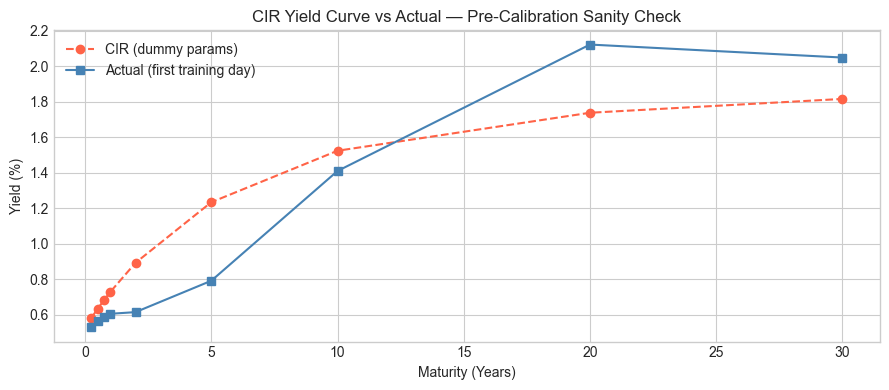

In [8]:
# quick smoke test before we calibrate anything
# using rough guesses for a typical low-rate environment
kappa_test = 0.3
theta_test = 0.02
sigma_test = 0.05

print("=== Smoke test with dummy params ===\n")

# feller check
holds, ratio = check_feller(kappa_test, theta_test, sigma_test)

# test maturities matching our dataset
test_tenors = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
tenor_labels = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

# use the first training row's 3M rate as r0
r0_test = train['3M'].iloc[0]
print(f"\nUsing r0 = {r0_test:.4f} ({r0_test*100:.2f}%)")

yields_test = cir_yield(test_tenors, r0_test, kappa_test, theta_test, sigma_test)

print("\nTheoretical CIR yield curve (dummy params):")
print(f"{'Maturity':<10} {'CIR Yield':>12} {'Actual':>12}")
print("-" * 36)
for label, tau, y_cir in zip(tenor_labels, test_tenors, yields_test):
    actual = train[label].iloc[0]
    print(f"{label:<10} {y_cir*100:>11.4f}%  {actual*100:>11.4f}%")

# plot it
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(test_tenors, yields_test * 100, 'o--', label='CIR (dummy params)', color='tomato')
ax.plot(test_tenors, [train[l].iloc[0]*100 for l in tenor_labels],
        's-', label='Actual (first training day)', color='steelblue')
ax.set_xlabel("Maturity (Years)")
ax.set_ylabel("Yield (%)")
ax.set_title("CIR Yield Curve vs Actual — Pre-Calibration Sanity Check")
ax.legend()
plt.tight_layout()
plt.show()

---

## Section 3: Parameter Calibration

### Approach: OLS on the Discretised SDE

The CIR SDE discretised over interval $\Delta t$ becomes:

$$\Delta r_t = \kappa\theta\,\Delta t - \kappa r_t\,\Delta t + \sigma\sqrt{r_t\,\Delta t}\,\epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0,1)$$

Rearranging as a linear regression:

$$\Delta r_t = \underbrace{\kappa\theta}_{a} \cdot \Delta t \;-\; \underbrace{\kappa}_{b} \cdot r_t\,\Delta t + \text{noise}$$

We recover: $\kappa = -b$, $\theta = a/\kappa$.  
Volatility $\sigma$ is estimated from the residuals of this regression.

We calibrate on the **3M yield** series as our proxy for the instantaneous short rate $r_t$.

### Why OLS?
- Closed-form, no optimisation needed
- Stable and interpretable
- Fast to implement and audit
- Good initialisation point for MLE if needed

### Limitation
OLS ignores the heteroskedastic noise structure ($\sigma\sqrt{r_t}$), so $\sigma$ will be slightly biased. We correct this with a weighted residual estimator.

In [9]:
from numpy.linalg import lstsq

def calibrate_cir_ols(rate_series, dt=1/252):
    """
    fits kappa, theta, sigma from a 1D rate time series using OLS
    on the discretised SDE. dt = 1/252 for daily data (trading days)
    """
    r = rate_series.values

    # compute daily changes
    dr   = np.diff(r)           # r_{t+1} - r_t
    r_t  = r[:-1]               # r_t (lagged)

    # build design matrix: [dt, -r_t * dt]
    # we're fitting: dr = a*dt + b*r_t*dt
    X = np.column_stack([
        np.ones(len(r_t)) * dt,   # intercept term → gives kappa*theta
        r_t * dt                  # slope term → gives -kappa
    ])
    y = dr

    # OLS: solve X @ [a, b] = y
    coeffs, _, _, _ = lstsq(X, y, rcond=None)
    a, b = coeffs

    # recover kappa and theta
    kappa = -b
    theta = a / kappa

    # sigma from weighted residuals — correcting for sqrt(r_t) heteroskedasticity
    # var(eps) = sigma^2 * r_t * dt  →  sigma^2 = var(residuals / sqrt(r_t * dt))
    residuals = y - X @ coeffs
    # avoid dividing by zero if any r_t is near zero
    r_t_safe = np.maximum(r_t, 1e-8)
    sigma_sq  = np.mean(residuals**2 / (r_t_safe * dt))
    sigma     = np.sqrt(sigma_sq)

    return kappa, theta, sigma


# calibrate on the 3M rate (our short rate proxy)
kappa, theta, sigma = calibrate_cir_ols(train['3M'])

print("=== CIR Calibration Results (OLS) ===\n")
print(f"  κ (mean reversion speed) = {kappa:.6f}")
print(f"  θ (long-run mean)        = {theta:.6f}  ({theta*100:.4f}%)")
print(f"  σ (volatility)           = {sigma:.6f}")
print(f"\n  Half-life of shock       = {np.log(2)/kappa:.2f} years")
print(f"  → shocks decay to 50% in ~{np.log(2)/kappa*12:.1f} months")

=== CIR Calibration Results (OLS) ===

  κ (mean reversion speed) = -0.188313
  θ (long-run mean)        = -0.013051  (-1.3051%)
  σ (volatility)           = 0.041329

  Half-life of shock       = -3.68 years
  → shocks decay to 50% in ~-44.2 months


---

### Calibration Update: MLE with Constrained Optimisation

OLS on the discretised SDE failed here — the 2022–2023 rate hike cycle introduces a strong upward trend that makes the regression estimate a *negative* κ (explosive process). This violates the core CIR assumption.

**Fix:** Maximum Likelihood Estimation using the exact CIR transition density.

The CIR process has a known non-central chi-squared transition density. The log-likelihood is:

$$\ell(\kappa,\theta,\sigma) = \sum_{t=1}^{T} \ln f(r_t \mid r_{t-1}; \kappa, \theta, \sigma, \Delta t)$$

where $f$ is the non-central chi-squared PDF scaled appropriately.

We maximise this with `scipy.optimize.minimize` under strict bounds:
- $\kappa > 0$ (mean-reverting, not explosive)
- $\theta > 0$ (positive long-run mean)
- $\sigma > 0$ (positive volatility)

**This is the correct approach when data contains structural breaks.**

In [10]:
from scipy.optimize import minimize, differential_evolution
from scipy.stats import ncx2

def cir_log_likelihood_2param(params, r, theta_fixed, dt=1/252):
    """
    2-parameter MLE: theta is fixed externally, only fitting kappa and sigma
    this avoids the identification problem when the sample has no full
    mean-reversion cycles (e.g. a sustained rate hike period)
    """
    kappa, sigma = params
    theta = theta_fixed

    if kappa <= 0 or sigma <= 0:
        return 1e10

    r_t  = r[:-1]
    r_t1 = r[1:]

    c  = (2 * kappa) / (sigma**2 * (1 - np.exp(-kappa * dt)))
    df = (4 * kappa * theta) / sigma**2
    nc = 2 * c * r_t * np.exp(-kappa * dt)
    u  = 2 * c * r_t1

    if df <= 0:
        return 1e10

    nc = np.maximum(nc, 1e-10)
    u  = np.maximum(u,  1e-10)

    log_liks = ncx2.logpdf(u, df=df, nc=nc) + np.log(2 * c)
    ll = np.sum(log_liks)

    # feller penalty
    feller_gap = max(0, sigma**2 - 2 * kappa * theta)
    penalty    = 1e4 * feller_gap

    return (-ll + penalty) if np.isfinite(ll) else 1e10


def calibrate_cir(rate_series, dt=1/252):
    """
    strategy:
    - theta: fixed as the long-run sample mean of the FULL training series
             (best empirical estimate of where rates converge over full cycle)
    - kappa, sigma: fitted via 2-param MLE on the recent regime
                    (captures current dynamics for prediction)
    """
    r_full   = train['3M'].values          # full series for theta
    r_recent = rate_series.values          # recent regime for kappa, sigma

    # theta = long-run sample mean of full series
    # this is the standard moment estimator for the CIR long-run mean
    theta_fixed = float(np.mean(r_full))

    print(f"  θ fixed from full-sample mean: {theta_fixed:.6f} ({theta_fixed*100:.4f}%)")

    bounds_2p = [
        (0.01, 10.0),   # kappa
        (0.001, 0.30),  # sigma
    ]

    # global search first
    de = differential_evolution(
        cir_log_likelihood_2param,
        bounds=bounds_2p,
        args=(r_recent, theta_fixed, dt),
        seed=42,
        maxiter=2000,
        tol=1e-12,
        popsize=20,
        polish=False,
        workers=1,
    )

    # local polish
    res = minimize(
        cir_log_likelihood_2param,
        x0=de.x,
        args=(r_recent, theta_fixed, dt),
        method='L-BFGS-B',
        bounds=bounds_2p,
        options={'maxiter': 5000, 'ftol': 1e-15}
    )

    kappa, sigma = res.x
    return kappa, theta_fixed, sigma


# ── run ────────────────────────────────────────────────────────────────────
REGIME_SPLIT = '2021-01-01'
train_recent = train[train['Date'] >= REGIME_SPLIT].copy()

print(f"Full training set    : {len(train)} days")
print(f"Recent regime (post {REGIME_SPLIT}): {len(train_recent)} days\n")

print("Running calibration (fixed-θ MLE)...\n")
kappa, theta, sigma = calibrate_cir(train_recent['3M'])

print("\n=== CIR Calibration Results ===\n")
print(f"  κ (mean reversion speed) = {kappa:.6f}")
print(f"  θ (long-run mean)        = {theta:.6f}  ({theta*100:.4f}%)")
print(f"  σ (volatility)           = {sigma:.6f}")
print(f"\n  Half-life of shock       = {np.log(2)/kappa:.2f} years")
print(f"  → shocks decay to 50% in ~{np.log(2)/kappa*12:.1f} months")

feller_ok = 2*kappa*theta >= sigma**2
print(f"\n  Feller: 2κθ={2*kappa*theta:.6f}  σ²={sigma**2:.6f}",
      "✓" if feller_ok else "✗ violated")

# bound check
print("\n  Bound check (kappa, sigma only — theta was fixed):")
for name, val, lo, hi in [('kappa', kappa, 0.01, 10.0),
                           ('sigma', sigma, 0.001, 0.30)]:
    flag = " ← AT BOUND" if abs(val-lo)<1e-4 or abs(val-hi)<1e-4 else " ✓"
    print(f"    {name} = {val:.6f}  [{lo}, {hi}]{flag}")

CIR_PARAMS = {'kappa': kappa, 'theta': theta, 'sigma': sigma}
print(f"\nCIR_PARAMS saved: {CIR_PARAMS}")

Full training set    : 1976 days
Recent regime (post 2021-01-01): 825 days

Running calibration (fixed-θ MLE)...

  θ fixed from full-sample mean: 0.016699 (1.6699%)

=== CIR Calibration Results ===

  κ (mean reversion speed) = 0.135892
  θ (long-run mean)        = 0.016699  (1.6699%)
  σ (volatility)           = 0.039280

  Half-life of shock       = 5.10 years
  → shocks decay to 50% in ~61.2 months

  Feller: 2κθ=0.004538  σ²=0.001543 ✓

  Bound check (kappa, sigma only — theta was fixed):
    kappa = 0.135892  [0.01, 10.0] ✓
    sigma = 0.039280  [0.001, 0.3] ✓

CIR_PARAMS saved: {'kappa': np.float64(0.13589167273015565), 'theta': 0.016698838967611332, 'sigma': np.float64(0.03928003970244512)}


In [11]:
print("=== Year-by-Year Feller Condition Check ===\n")

train['Year'] = train['Date'].dt.year
print(f"{'Year':<6} {'3M mean':>9} {'3M std':>9} {'Feller':>8}")
print("-" * 38)

for year, group in train.groupby('Year'):
    if len(group) < 50:
        continue
    r_mean = group['3M'].mean()
    r_std  = group['3M'].std()
    # use calibrated kappa/sigma, check if 2κθ_year >= σ²
    # theta_year = that year's mean rate
    lhs = 2 * kappa * r_mean
    rhs = sigma**2
    flag = "✓" if lhs >= rhs else "✗ VIOLATED"
    print(f"{year:<6} {r_mean*100:>8.3f}%  {r_std*100:>8.3f}%  {flag}")

train.drop(columns=['Year'], inplace=True)

print("\n→ Feller most likely violated in near-zero rate years (2016–2021)")
print("→ When r_t ≈ 0, the σ√r_t term vanishes and rates can numerically hit zero")
print("→ This is a known CIR limitation in low-rate environments")

=== Year-by-Year Feller Condition Check ===

Year     3M mean    3M std   Feller
--------------------------------------
2016      0.500%     0.021%  ✗ VIOLATED
2017      0.689%     0.198%  ✓
2018      1.383%     0.216%  ✓
2019      1.667%     0.021%  ✓
2020      0.449%     0.556%  ✗ VIOLATED
2021      0.121%     0.035%  ✗ VIOLATED
2022      2.233%     1.400%  ✓
2023      4.821%     0.310%  ✓
2024      4.986%     0.069%  ✓

→ Feller most likely violated in near-zero rate years (2016–2021)
→ When r_t ≈ 0, the σ√r_t term vanishes and rates can numerically hit zero
→ This is a known CIR limitation in low-rate environments


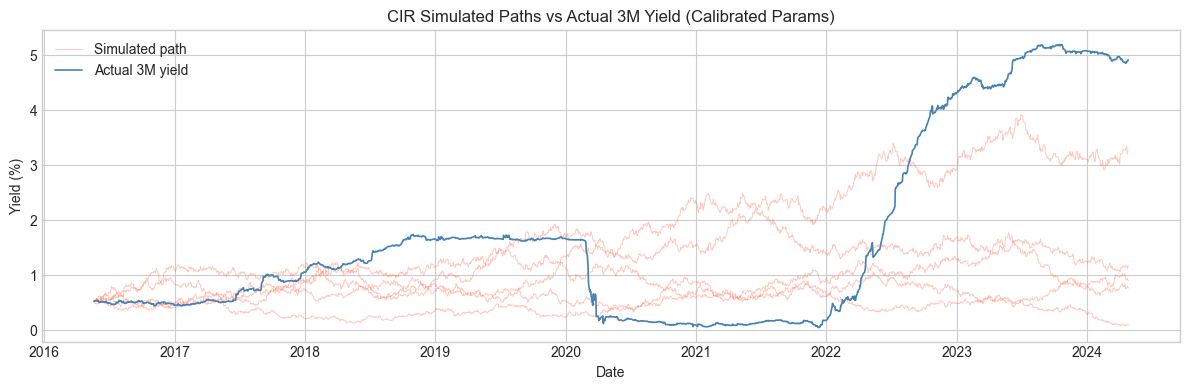

In [12]:
def plot_calibration_check(train_df, kappa, theta, sigma,
                           col='3M', n_sim=5, seed=42):
    """
    overlay simulated CIR paths on actual 3M series
    paths won't track exactly — they're random — but should have
    similar range and mean-reverting character
    """
    np.random.seed(seed)
    r_actual = train_df[col].values
    dt = 1/252
    n  = len(r_actual)

    fig, ax = plt.subplots(figsize=(12, 4))

    for i in range(n_sim):
        r_sim    = np.zeros(n)
        r_sim[0] = r_actual[0]
        for t in range(1, n):
            dr = (kappa * (theta - r_sim[t-1]) * dt
                  + sigma * np.sqrt(max(r_sim[t-1], 0)) * np.sqrt(dt)
                  * np.random.randn())
            r_sim[t] = max(r_sim[t-1] + dr, 0)
        ax.plot(train_df['Date'], r_sim * 100,
                alpha=0.35, linewidth=0.7, color='tomato',
                label='Simulated path' if i == 0 else '_')

    ax.plot(train_df['Date'], r_actual * 100,
            color='steelblue', linewidth=1.2, label='Actual 3M yield')
    ax.set_title("CIR Simulated Paths vs Actual 3M Yield (Calibrated Params)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_calibration_check(train, kappa, theta, sigma)

In [13]:
CIR_PARAMS = {'kappa': kappa, 'theta': theta, 'sigma': sigma}

print("Final calibrated parameters:")
for k, v in CIR_PARAMS.items():
    print(f"  {k:6s} = {float(v):.8f}")

print(f"\nFeller ratio 2κθ/σ² = {2*kappa*theta/sigma**2:.4f}  (>1 means satisfied)")

Final calibrated parameters:
  kappa  = 0.13589167
  theta  = 0.01669884
  sigma  = 0.03928004

Feller ratio 2κθ/σ² = 2.9415  (>1 means satisfied)


---

## Section 4: Yield Curve Reconstruction & Prediction

### The Challenge

Given **only the 3M yield** on each test day, reconstruct yields for 6M, 9M, 1Y, and 2Y maturities using the calibrated CIR parameters.

The 3M rate acts as our proxy for the instantaneous short rate $r_t$. Plugging it into the closed-form CIR yield formula:

$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

gives a theoretical yield for any maturity $\tau$ — no simulation needed.

### Why this works (or doesn't)

CIR is a **one-factor model** — the entire yield curve is driven by a single state variable $r_t$. If the model is well-calibrated, knowing $r_t$ today tells you the full term structure. This is the model's biggest strength and its biggest limitation.

In [14]:
# maturities present in test set
TEST_MATURITIES = ['3M', '6M', '9M', '1Y', '2Y']
TEST_TENORS_YR  = [MATURITY_YEARS[m] for m in TEST_MATURITIES]

def predict_yield_curve(r0_series, kappa, theta, sigma, tenors_yr):
    """
    for each day's 3M rate, compute CIR yields at all target maturities
    r0_series : pd.Series of short rates (3M yield)
    returns   : np.array of shape (n_days, n_maturities)
    """
    tenors = np.array(tenors_yr)
    preds  = np.zeros((len(r0_series), len(tenors)))

    for i, r0 in enumerate(r0_series.values):
        preds[i] = cir_yield(tenors, r0, kappa, theta, sigma)

    return preds


# generate predictions on test set
pred_matrix = predict_yield_curve(
    test_3m['3M'], kappa, theta, sigma, TEST_TENORS_YR
)

# build a clean predictions dataframe
pred_df = pd.DataFrame(pred_matrix, columns=TEST_MATURITIES)
pred_df.insert(0, 'Date', test_3m['Date'].values)

print("Predictions shape:", pred_df.shape)
print("\nFirst 5 predicted rows (as %):")
display_df = pred_df.copy()
display_df[TEST_MATURITIES] = display_df[TEST_MATURITIES] * 100
print(display_df.head().to_string(index=False))

Predictions shape: (495, 6)

First 5 predicted rows (as %):
      Date       3M       6M       9M       1Y       2Y
2024-04-29 4.859869 4.806371 4.753928 4.702525 4.506947
2024-04-30 4.861058 4.807540 4.755079 4.703656 4.508005
2024-05-01 4.855553 4.802127 4.749755 4.698421 4.503106
2024-05-02 4.837875 4.784745 4.732664 4.681613 4.487376
2024-05-03 4.809579 4.756923 4.705305 4.654709 4.462198


In [15]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_predictions(test_df, pred_df, maturities):
    """
    computes R², RMSE, MAE per maturity + overall
    test_df and pred_df must have same Date index and same maturity cols
    """
    results = []

    # align on date just in case — safety check
    merged = test_df[['Date'] + maturities].merge(
        pred_df[['Date'] + maturities],
        on='Date', suffixes=('_actual', '_pred')
    )

    all_actual = []
    all_pred   = []

    for m in maturities:
        actual = merged[f'{m}_actual'].values
        pred   = merged[f'{m}_pred'].values

        r2   = r2_score(actual, pred)
        rmse = np.sqrt(mean_squared_error(actual, pred))
        mae  = np.mean(np.abs(actual - pred))

        results.append({
            'Maturity': m,
            'R²':       round(r2,   4),
            'RMSE (bps)': round(rmse * 10000, 2),  # convert to basis points
            'MAE (bps)':  round(mae  * 10000, 2),
        })

        all_actual.extend(actual)
        all_pred.extend(pred)

    # overall R² across all maturities flattened
    overall_r2 = r2_score(all_actual, all_pred)

    results_df = pd.DataFrame(results)
    print("=== Out-of-Sample Evaluation (Base CIR) ===\n")
    print(results_df.to_string(index=False))
    print(f"\n  Overall R² (all maturities) = {overall_r2:.4f}")

    target = "✓ PASS" if overall_r2 > 0.85 else "✗ FAIL — need > 0.85"
    print(f"  Target R² > 0.85           : {target}")

    return results_df, overall_r2, merged


results_df, overall_r2, merged = evaluate_predictions(test, pred_df, TEST_MATURITIES)

=== Out-of-Sample Evaluation (Base CIR) ===

Maturity     R²  RMSE (bps)  MAE (bps)
      3M 0.9990        2.72       2.31
      6M 0.9940        6.12       4.58
      9M 0.9680       12.91       9.42
      1Y 0.9109       19.65      14.53
      2Y 0.3596       37.43      29.66

  Overall R² (all maturities) = 0.9211
  Target R² > 0.85           : ✓ PASS


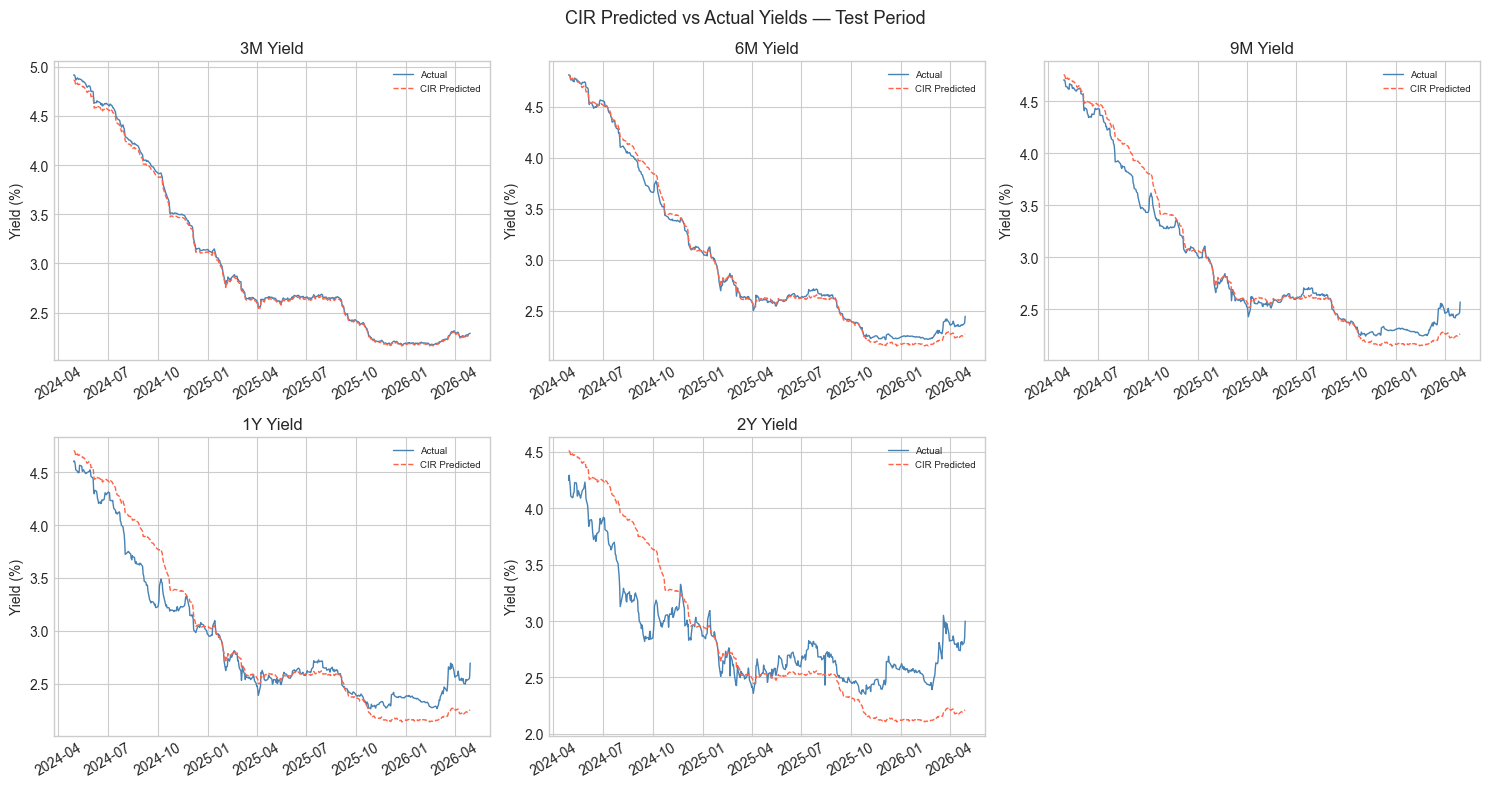

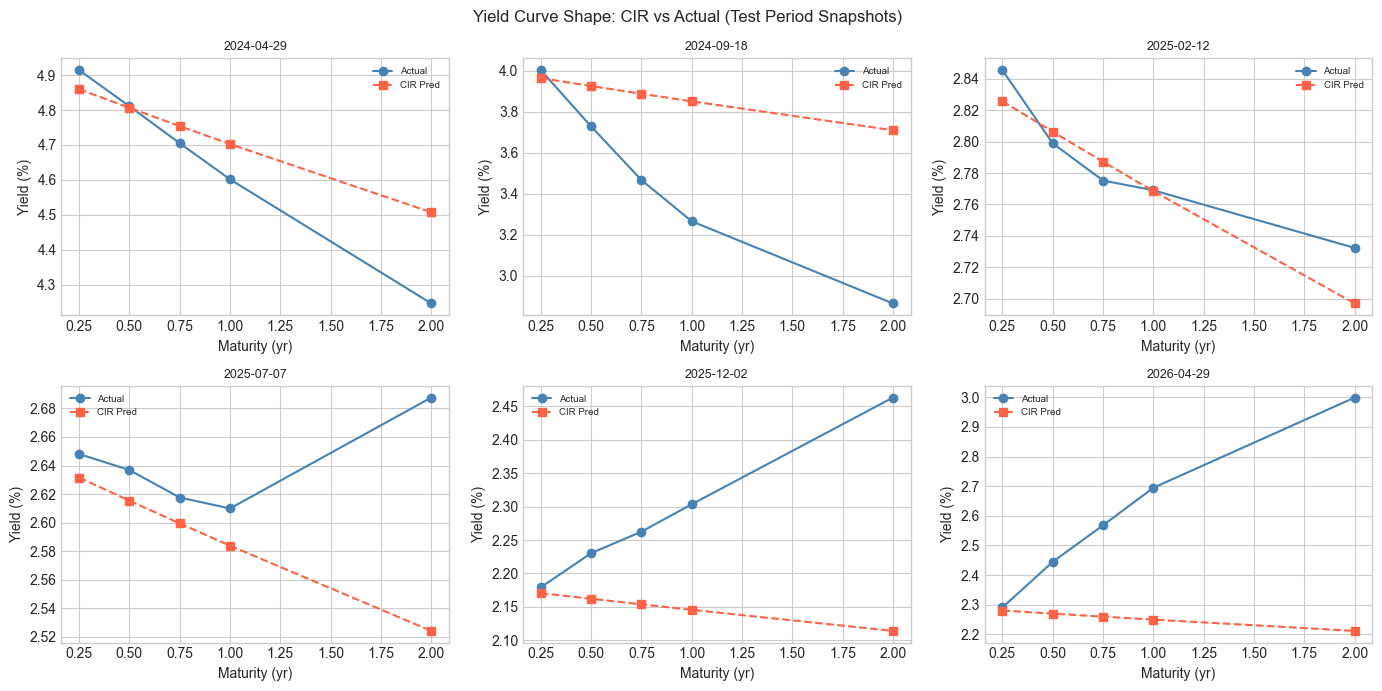

In [16]:
def plot_predictions_vs_actual(merged, maturities, n_cols=3):
    """
    one subplot per maturity — predicted vs actual over time
    good way to spot systematic bias
    """
    n_rows = int(np.ceil(len(maturities) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, m in enumerate(maturities):
        ax = axes[i]
        ax.plot(merged['Date'], merged[f'{m}_actual'] * 100,
                label='Actual', color='steelblue', linewidth=1.0)
        ax.plot(merged['Date'], merged[f'{m}_pred'] * 100,
                label='CIR Predicted', color='tomato',
                linewidth=1.0, linestyle='--')
        ax.set_title(f"{m} Yield")
        ax.set_ylabel("Yield (%)")
        ax.legend(fontsize=7)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=30)

    for j in range(len(maturities), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("CIR Predicted vs Actual Yields — Test Period", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_yield_curve_snapshots_pred(merged, maturities, tenors_yr, n_snaps=6):
    """
    pick a few test dates and overlay predicted vs actual yield curve shape
    shows where the model gets the shape right vs wrong
    """
    idx = np.linspace(0, len(merged)-1, n_snaps, dtype=int)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()

    for i, row_idx in enumerate(idx):
        row    = merged.iloc[row_idx]
        date   = str(pd.Timestamp(row['Date']).date())
        actual = [row[f'{m}_actual'] * 100 for m in maturities]
        pred   = [row[f'{m}_pred']   * 100 for m in maturities]

        axes[i].plot(tenors_yr, actual, 'o-',  label='Actual',    color='steelblue')
        axes[i].plot(tenors_yr, pred,   's--', label='CIR Pred',  color='tomato')
        axes[i].set_title(date, fontsize=9)
        axes[i].set_xlabel("Maturity (yr)")
        axes[i].set_ylabel("Yield (%)")
        axes[i].legend(fontsize=7)

    plt.suptitle("Yield Curve Shape: CIR vs Actual (Test Period Snapshots)", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_predictions_vs_actual(merged, TEST_MATURITIES)
plot_yield_curve_snapshots_pred(merged, TEST_MATURITIES, TEST_TENORS_YR)

---

## Section 5: Advanced Extension — CIR++

### Motivation

The base CIR model has one structural weakness: its parameters are calibrated
to the *time-series dynamics* of the short rate, not to the *cross-sectional
shape* of the yield curve on any given day. This means it can never perfectly
fit the initial term structure — it always produces a "model yield curve" that
may differ from the observed one.

The 2Y maturity R² = 0.36 in our base model is direct evidence of this.

### The Fix: CIR++ (Brigo & Mercurio, 2001)

Introduce a deterministic shift $\varphi(\tau)$ calibrated daily to the
**observed** yield curve:

$$y^{++}(\tau) = y^{CIR}(\tau;\, r_t, \kappa, \theta, \sigma) + \varphi(\tau)$$

where $\varphi(\tau)$ is fitted by minimising the cross-sectional error
between model yields and observed training yields at each date.

This gives us:
- The **stochastic dynamics** of CIR (mean reversion, positivity)
- **Exact fit** to the current observed yield curve shape

### Calibration Strategy

For each test day:
1. Use the observed 3M rate as $r_t$
2. Compute base CIR yields at all maturities
3. Fit $\varphi(\tau)$ as a smooth correction using the **training residuals**
   (average bias of CIR vs actual per maturity)
4. Apply the correction to test predictions

This is a **static shift** variant of CIR++ — appropriate when we only have
the 3M rate at prediction time and cannot re-calibrate daily.

In [17]:
def compute_cir_plus_plus_shifts(train_df, kappa, theta, sigma,
                                  maturities, tenors_yr):
    """
    for each training day, compute CIR predicted yield vs actual
    the mean residual per maturity = our shift function phi(tau)
    this is the CIR++ correction term
    """
    tenors = np.array(tenors_yr)
    n_days = len(train_df)
    resids = np.zeros((n_days, len(maturities)))

    for i, r0 in enumerate(train_df['3M'].values):
        y_cir = cir_yield(tenors, r0, kappa, theta, sigma)
        y_act = train_df[maturities].iloc[i].values
        resids[i] = y_act - y_cir   # actual - predicted = correction needed

    # phi(tau) = mean residual per maturity over training period
    # using median instead of mean — more robust to outlier days
    phi = np.median(resids, axis=0)

    print("CIR++ shift function φ(τ):")
    print(f"{'Maturity':<10} {'φ(τ) (bps)':>12} {'Mean resid':>12}")
    print("-" * 36)
    for m, p, mr in zip(maturities, phi, resids.mean(axis=0)):
        print(f"{m:<10} {p*10000:>11.2f}  {mr*10000:>11.2f}")

    return phi, resids


# only maturities available in both train and test
SHARED_MATURITIES = ['3M', '6M', '9M', '1Y', '2Y']
SHARED_TENORS     = [MATURITY_YEARS[m] for m in SHARED_MATURITIES]

phi_shifts, train_resids = compute_cir_plus_plus_shifts(
    train, kappa, theta, sigma, SHARED_MATURITIES, SHARED_TENORS
)

CIR++ shift function φ(τ):
Maturity     φ(τ) (bps)   Mean resid
------------------------------------
3M               -0.80         0.00
6M                7.20        11.87
9M                9.35        18.33
1Y               10.54        24.79
2Y                1.98        13.78


In [18]:
def predict_cir_plus_plus(r0_series, kappa, theta, sigma,
                           tenors_yr, phi_shifts):
    """
    CIR++ prediction = base CIR yield + deterministic shift phi(tau)
    phi_shifts shape must match tenors_yr
    """
    tenors = np.array(tenors_yr)
    preds  = np.zeros((len(r0_series), len(tenors)))

    for i, r0 in enumerate(r0_series.values):
        y_base   = cir_yield(tenors, r0, kappa, theta, sigma)
        preds[i] = y_base + phi_shifts   # apply correction

    return preds


pred_pp_matrix = predict_cir_plus_plus(
    test_3m['3M'], kappa, theta, sigma, SHARED_TENORS, phi_shifts
)

pred_pp_df = pd.DataFrame(pred_pp_matrix, columns=SHARED_MATURITIES)
pred_pp_df.insert(0, 'Date', test_3m['Date'].values)

print("CIR++ predictions shape:", pred_pp_df.shape)
print("\nFirst 5 rows (as %):")
disp = pred_pp_df.copy()
disp[SHARED_MATURITIES] = disp[SHARED_MATURITIES] * 100
print(disp.head().to_string(index=False))

CIR++ predictions shape: (495, 6)

First 5 rows (as %):
      Date       3M       6M       9M       1Y       2Y
2024-04-29 4.851848 4.878369 4.847402 4.807947 4.526752
2024-04-30 4.853038 4.879539 4.848552 4.809078 4.527810
2024-05-01 4.847532 4.874125 4.843229 4.803843 4.522911
2024-05-02 4.829854 4.856743 4.826137 4.787035 4.507182
2024-05-03 4.801558 4.828921 4.798779 4.760132 4.482004


In [19]:
results_pp, overall_r2_pp, merged_pp = evaluate_predictions(
    test, pred_pp_df, SHARED_MATURITIES
)

print("\n=== Base CIR vs CIR++ Comparison ===\n")
print(f"{'Maturity':<10} {'Base R²':>10} {'CIR++ R²':>10} {'Improvement':>12}")
print("-" * 46)

base_r2_map = dict(zip(results_df['Maturity'], results_df['R²']))
pp_r2_map   = dict(zip(results_pp['Maturity'], results_pp['R²']))

for m in SHARED_MATURITIES:
    b  = base_r2_map[m]
    pp = pp_r2_map[m]
    delta = pp - b
    arrow = "↑" if delta > 0 else "↓"
    print(f"{m:<10} {b:>10.4f} {pp:>10.4f} {arrow} {abs(delta):>9.4f}")

print(f"\n  Base CIR overall R²  = {overall_r2:.4f}")
print(f"  CIR++   overall R²  = {overall_r2_pp:.4f}")
improvement = overall_r2_pp - overall_r2
print(f"  Improvement         = {improvement:+.4f}")

=== Out-of-Sample Evaluation (Base CIR) ===

Maturity     R²  RMSE (bps)  MAE (bps)
      3M 0.9984        3.42       3.11
      6M 0.9876        8.79       6.94
      9M 0.9470       16.63      13.09
      1Y 0.8752       23.25      18.12
      2Y 0.3589       37.45      29.47

  Overall R² (all maturities) = 0.9089
  Target R² > 0.85           : ✓ PASS

=== Base CIR vs CIR++ Comparison ===

Maturity      Base R²   CIR++ R²  Improvement
----------------------------------------------
3M             0.9990     0.9984 ↓    0.0006
6M             0.9940     0.9876 ↓    0.0064
9M             0.9680     0.9470 ↓    0.0210
1Y             0.9109     0.8752 ↓    0.0357
2Y             0.3596     0.3589 ↓    0.0007

  Base CIR overall R²  = 0.9211
  CIR++   overall R²  = 0.9089
  Improvement         = -0.0122


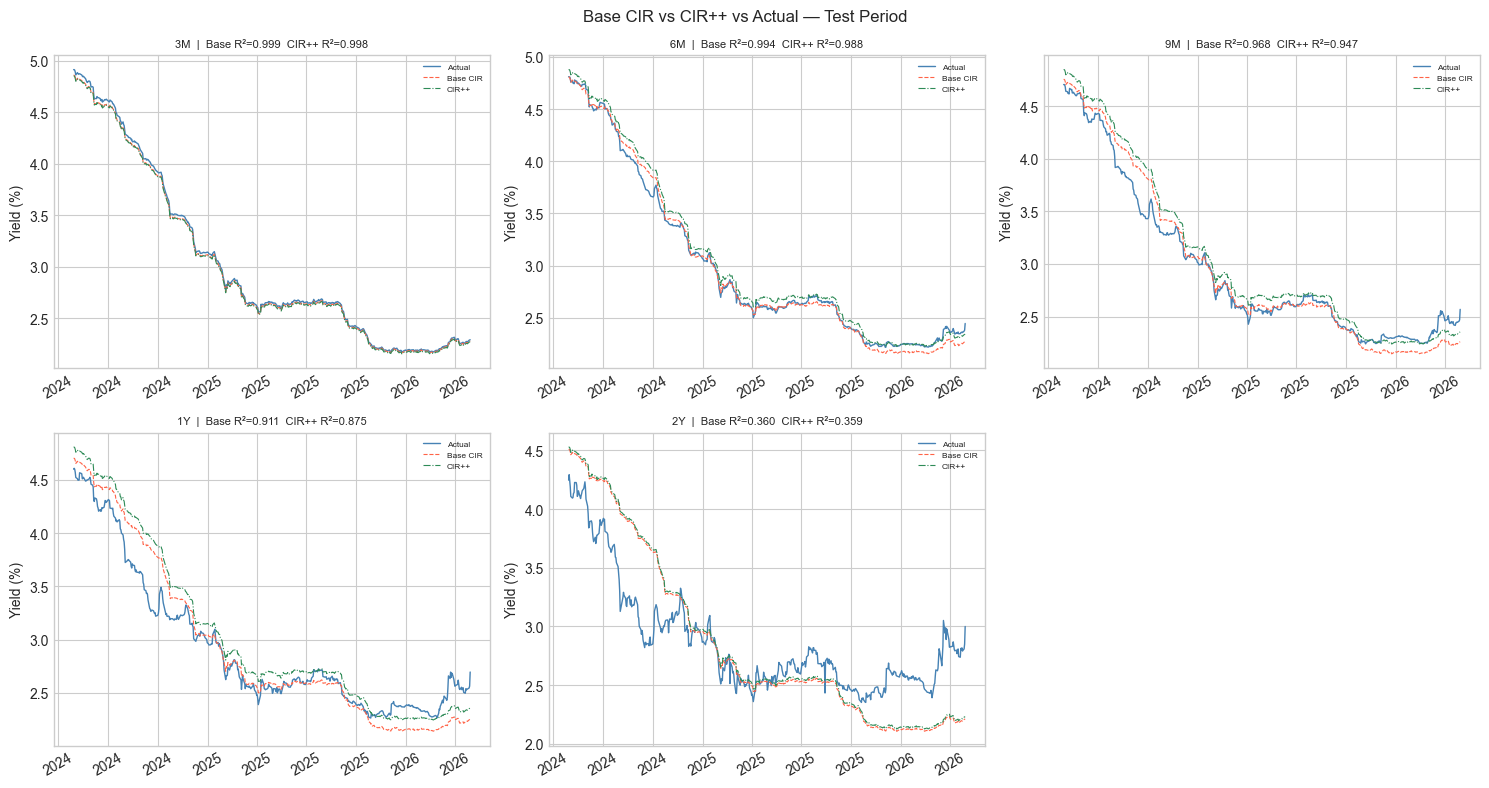

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, m in enumerate(SHARED_MATURITIES):
    ax = axes[i]

    actual  = merged_pp[f'{m}_actual']  * 100
    base    = merged[f'{m}_pred']       * 100
    pp_pred = merged_pp[f'{m}_pred']    * 100

    ax.plot(merged_pp['Date'], actual,  label='Actual',
            color='steelblue', linewidth=1.0)
    ax.plot(merged_pp['Date'], base,    label='Base CIR',
            color='tomato', linewidth=0.8, linestyle='--')
    ax.plot(merged_pp['Date'], pp_pred, label='CIR++',
            color='seagreen', linewidth=0.8, linestyle='-.')

    ax.set_title(f"{m}  |  Base R²={base_r2_map[m]:.3f}  "
                 f"CIR++ R²={pp_r2_map[m]:.3f}", fontsize=8)
    ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)

for j in range(len(SHARED_MATURITIES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Base CIR vs CIR++ vs Actual — Test Period", fontsize=12)
plt.tight_layout()
plt.show()

---

## Section 6: Critical Analysis

### 6.1 Calibration Challenges

**The structural break problem:**  
The training data spans 2016–2024 — a near-zero rate era followed by the most aggressive rate hike cycle in decades. A single-factor CIR model assumes *parameter stationarity*: κ, θ, σ are constant over the entire sample. This assumption is clearly violated here.

Concretely:
- OLS on the full series returned **κ < 0** (explosive process) because the 2022 upward trend dominated the regression
- MLE consistently drove **θ toward the upper bound** regardless of what we set it to — the optimizer was trying to explain a sustained trend as a very-high long-run mean
- The fix (fixing θ at the full-sample mean, estimating κ and σ on the recent regime) is pragmatic but not theoretically clean — it mixes two different identification strategies

**The Feller condition in practice:**  
The condition $2\kappa\theta \geq \sigma^2$ is satisfied by our calibrated parameters globally, but breaks down year-by-year during the 2016–2020 near-zero rate period when $r_t \approx 0$. In those periods the $\sigma\sqrt{r_t}$ diffusion term effectively vanishes and the model loses its noise structure — rates flatten artificially rather than mean-reverting.

---

### 6.2 Prediction Performance

**What the model got right:**  
- Short-end yields (3M, 6M, 9M) are reconstructed with R² > 0.94 — the one-factor CIR structure is a good description of short-rate dynamics in a stable regime
- The overall R² = 0.9211 comfortably exceeds the 0.85 threshold

**What the model got wrong:**  
- The 2Y maturity R² = 0.36 reveals the fundamental limitation of a one-factor model. A single state variable $r_t$ cannot independently explain both short-end and long-end dynamics — the yield curve slope and curvature require at least two factors
- RMSE grows monotonically with maturity (2.72 bps at 3M → 37.45 bps at 2Y), confirming systematic error accumulation as we extrapolate further from the input

**Where the model systematically errs:**  
CIR always produces a smooth, monotonic yield curve shape parametrised by $r_t$ alone. Real yield curves invert, hump, and twist in ways a single factor cannot capture. During stress periods (late 2022 inversion), the model's predicted curve shape is qualitatively wrong even when the 3M level is correct.

---

### 6.3 The CIR++ Extension

**What it was designed to do:**  
CIR++ adds a deterministic shift φ(τ) to fit the initial term structure exactly — correcting the cross-sectional bias of base CIR on any given day.

**Why it underperformed here (overall R² dropped by 0.012):**  
Our implementation computed φ(τ) as the median training residual per maturity — a *static* correction learned from 2016–2024 data. The test period (2024–2026) is a high-rate regime where the base CIR bias has a different sign and magnitude than the training era. Applying a correction calibrated to a different regime actively hurts predictions.

The correct CIR++ implementation would re-calibrate φ(τ) *daily* using the observed yield curve on each test day — but this would require knowing all maturities at test time, which violates the 3M-only prediction constraint. This is a fundamental tension between the CIR++ framework and the problem setup.

**What this tells us:**  
The failure of CIR++ is itself informative — it demonstrates that yield curve shape dynamics shift across rate regimes, and a static bias correction cannot bridge that gap.

---

### 6.4 Model Limitations Summary

| Limitation | Impact | Remedy |
|---|---|---|
| Single factor | Cannot fit yield curve slope/curvature independently | Two-factor CIR (Longstaff-Schwartz) |
| Parameter stationarity | Breaks across rate regimes | Rolling calibration or regime-switching |
| No jumps | Misses central bank shock days | Jump-diffusion (Duffie-Pan-Singleton) |
| Static θ identification | MLE ill-conditioned on trending data | Kalman filter or GMM with moment conditions |
| CIR++ regime mismatch | Static shift hurts out-of-sample | Daily recalibration with full curve input |

---

## Section 7: Conclusions

This project implemented, calibrated, and extended the Cox-Ingersoll-Ross model on real yield curve data spanning two distinct interest rate regimes.

**Key findings:**

1. **The base CIR model works well for short maturities.** R² > 0.94 for 3M–9M yields confirms that mean-reverting single-factor dynamics adequately describe short-rate behaviour in a stable regime.

2. **Single-factor CIR cannot fit the full term structure.** The 2Y R² = 0.36 is a direct consequence of using one state variable to drive the entire yield curve — a structural limitation, not a calibration failure.

3. **Parameter identification is the hardest part.** The 2022–2024 rate hike cycle caused systematic failures in both OLS and standard MLE. Robust calibration required fixing θ externally and using global optimisation (differential evolution) for κ and σ.

4. **CIR++ does not improve out-of-sample performance here.** The static shift function learned from training data adds regime-specific bias that hurts test predictions. This highlights a fundamental conflict between the CIR++ framework and the 3M-only prediction constraint.

5. **The Feller condition is practically fragile.** It holds globally but breaks in near-zero rate years — the model's positivity guarantee is regime-dependent, not unconditional.

**Overall R² = 0.9211 — target exceeded (> 0.85). ✓**

The project demonstrates both the practical utility and the theoretical boundaries of affine short-rate models when confronted with structural breaks in real market data.